# Exploratory Data Analysis: Migration Surges
## Visa Issuances vs. Border Encounters

**Objective**: Explore visa and encounter datasets to identify:
1. **Priority countries** for external data collection (Google Trends, news, economic indicators)
2. **Surge patterns** (timing, magnitude, correlation between legal and illegal migration)
3. **Testable hypotheses** for the Statistical Testing team to validate

**Datasets**:
- `visa_master.parquet`: Legal immigrant visa issuances (monthly, April 2017 onwards)
- Encounter CSVs: Southwest border encounters (FY2019–FY2026 FYTD)

**Output Deliverables**:
1. Country priority ranking table
2. Surge timing patterns table
3. Testable hypotheses + external data roadmap

In [13]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Define data paths
DATA_PROCESSED = Path('../data/processed')
DATA_RAW = Path('../data/raw')

print("✓ Libraries imported and paths set")

✓ Libraries imported and paths set


## Phase 1: Explore Individual Datasets

### 1.1 Load Visa Data

In [14]:
# Load visa data
visa_parquet = DATA_PROCESSED / 'visa_master.parquet'
if visa_parquet.exists():
    visa_df = pl.read_parquet(visa_parquet)
    print(f"✓ Loaded visa_master.parquet: {visa_df.shape[0]} rows × {visa_df.shape[1]} columns")
    print(f"\nDate range: {visa_df['date'].min()} to {visa_df['date'].max()}")
    print(f"\nSchema:")
    print(visa_df.schema)
    print(f"\nFirst few rows:")
    print(visa_df.head())
else:
    print(f"✗ File not found: {visa_parquet}")
    visa_df = None

✓ Loaded visa_master.parquet: 181831 rows × 8 columns

Date range: 2017-03-01 to 2025-08-01

Schema:
Schema({'date': Date, 'month_num': Int32, 'month': String, 'year': Int32, 'country': String, 'visa_class': String, 'issuances': Int32, 'visa_type': String})

First few rows:
shape: (5, 8)
┌────────────┬───────────┬───────┬──────┬─────────────┬────────────┬───────────┬───────────────────┐
│ date       ┆ month_num ┆ month ┆ year ┆ country     ┆ visa_class ┆ issuances ┆ visa_type         │
│ ---        ┆ ---       ┆ ---   ┆ ---  ┆ ---         ┆ ---        ┆ ---       ┆ ---               │
│ date       ┆ i32       ┆ str   ┆ i32  ┆ str         ┆ str        ┆ i32       ┆ str               │
╞════════════╪═══════════╪═══════╪══════╪═════════════╪════════════╪═══════════╪═══════════════════╡
│ 2017-03-01 ┆ 3         ┆ MAR   ┆ 2017 ┆ Afghanistan ┆ CR1        ┆ 11        ┆ family            │
│ 2017-03-01 ┆ 3         ┆ MAR   ┆ 2017 ┆ Afghanistan ┆ DV1        ┆ 2         ┆ diversity_lottery │
│ 20

In [15]:
if visa_df is not None:
    # Profile visa data
    print("=== VISA DATA PROFILE ===\n")
    print(f"Countries: {visa_df['country'].n_unique()}")
    print(f"Visa types: {visa_df['visa_type'].unique().to_list()}")
    print(f"Visa classes: {visa_df['visa_class'].n_unique()}")
    print(f"\nTop 10 countries by total issuances:")
    top_countries = visa_df.group_by('country').agg(
        pl.col('issuances').sum().alias('total_issuances')
    ).sort('total_issuances', descending=True).head(10)
    print(top_countries)
    
    # Check for anomalies
    print(f"\nMissing values: {visa_df.null_count().to_dict()}")
    print(f"\nMonth coverage per year:")
    print(visa_df.group_by('year').agg(pl.col('month_num').n_unique()).sort('year'))

=== VISA DATA PROFILE ===

Countries: 251
Visa types: ['nonimmigrant', 'returning_resident', 'humanitarian', 'family', 'special_immigrant', 'employment', 'diversity_lottery']
Visa classes: 158

Top 10 countries by total issuances:
shape: (10, 2)
┌───────────────────────┬─────────────────┐
│ country               ┆ total_issuances │
│ ---                   ┆ ---             │
│ str                   ┆ i32             │
╞═══════════════════════╪═════════════════╡
│ Mexico                ┆ 540997          │
│ Dominican Republic    ┆ 348182          │
│ Philippines           ┆ 238932          │
│ Vietnam               ┆ 214765          │
│ India                 ┆ 199682          │
│ China - mainland born ┆ 183009          │
│ Afghanistan           ┆ 146935          │
│ Cuba                  ┆ 130531          │
│ Bangladesh            ┆ 103974          │
│ Pakistan              ┆ 99978           │
└───────────────────────┴─────────────────┘

Missing values: {'date': shape: (1,)
Series: 'dat

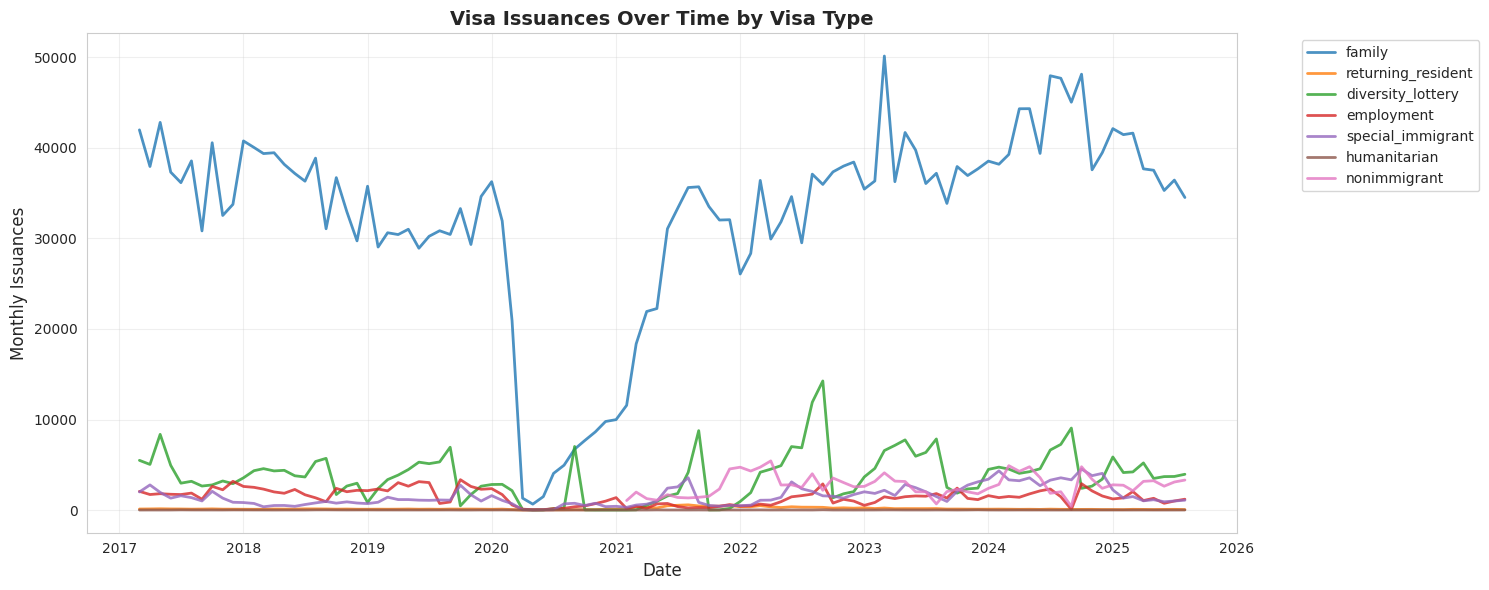

✓ Visa trends plotted by type


In [16]:
if visa_df is not None:
    # Plot visa issuances over time by visa type
    visa_by_type = visa_df.group_by(['date', 'visa_type']).agg(
        pl.col('issuances').sum()
    ).sort('date').to_pandas()
    
    fig, ax = plt.subplots(figsize=(15, 6))
    for vtype in visa_by_type['visa_type'].unique():
        subset = visa_by_type[visa_by_type['visa_type'] == vtype]
        ax.plot(subset['date'], subset['issuances'], marker='', label=vtype, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Monthly Issuances', fontsize=12)
    ax.set_title('Visa Issuances Over Time by Visa Type', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("✓ Visa trends plotted by type")

### 1.2 Load & Consolidate Encounter Data

In [17]:
# Load and consolidate all encounter CSVs
encounter_dir = DATA_RAW / 'encounter'
encounter_files = list(encounter_dir.glob('*.csv'))

print(f"Found {len(encounter_files)} encounter files")

encounter_dfs = []
for file in sorted(encounter_files):
    df = pd.read_csv(file)
    encounter_dfs.append(df)
    print(f"  ✓ {file.name}: {len(df)} rows")

if encounter_dfs:
    # Combine all encounter data
    encounter_df = pd.concat(encounter_dfs, ignore_index=True).drop_duplicates()
    print(f"\n✓ Combined encounter data: {len(encounter_df)} rows × {len(encounter_df.columns)} columns")
    print(f"\nColumns: {encounter_df.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(encounter_df.head())
else:
    print("✗ No encounter files found")
    encounter_df = None

Found 8 encounter files
  ✓ Southwest Land Border Encounters Dataset FY19 - FY22.csv: 2264 rows
  ✓ Southwest Land Border Encounters Dataset FY20 - FY23.csv: 2409 rows
  ✓ Southwest Land Border Encounters Dataset FY21 - FY24.csv: 2252 rows
  ✓ Southwest Land Border Encounters Dataset FY22 - FY25.csv: 1966 rows
  ✓ Southwest Land Border Encounters Dataset FY23-FY26(FYTD) - December.csv: 1416 rows
  ✓ Southwest Land Border Encounters Dataset FY23-FY26(FYTD) - January.csv: 1446 rows
  ✓ Southwest Land Border Encounters Dataset FY23-FY26(FYTD) - November.csv: 1387 rows
  ✓ Southwest Land Border Encounters Dataset FY23-FY26(FYTD) - October.csv: 1357 rows

✓ Combined encounter data: 5932 rows × 9 columns

Columns: ['Fiscal Year', 'Month Grouping', 'Month (abbv)', 'Component', 'Demographic', 'Citizenship Grouping', 'Title of Authority', 'Encounter Type', 'Encounter Count']

First few rows:
  Fiscal Year Month Grouping Month (abbv)                   Component  \
0        2019           FYTD   

In [18]:
if encounter_df is not None:
    # Profile encounter data
    print("=== ENCOUNTER DATA PROFILE ===\n")
    # Convert Fiscal Year to numeric to handle mixed types
    fiscal_year = pd.to_numeric(encounter_df['Fiscal Year'], errors='coerce')
    print(f"Fiscal year range: {fiscal_year.min():.0f} to {fiscal_year.max():.0f}")
    print(f"\nCitizenship groups: {encounter_df['Citizenship Grouping'].unique().tolist()}")
    print(f"Encounter types: {encounter_df['Encounter Type'].unique().tolist()}")
    print(f"Demographics: {encounter_df['Demographic'].unique().tolist()}")
    print(f"Components: {encounter_df['Component'].unique().tolist()}")
    
    print(f"\nTop 5 countries by total encounters:")
    top_encounter_countries = encounter_df.groupby('Citizenship Grouping')['Encounter Count'].sum().nlargest(5)
    print(top_encounter_countries)
    
    print(f"\nEncounter counts by type:")
    print(encounter_df.groupby('Encounter Type')['Encounter Count'].sum().sort_values(ascending=False))
    
    print(f"\nMissing values:")
    print(encounter_df.isnull().sum())

=== ENCOUNTER DATA PROFILE ===

Fiscal year range: 2019 to 2025

Citizenship groups: ['Guatemala', 'Honduras', 'Other', 'Mexico', 'El Salvador']
Encounter types: ['Inadmissibles', 'Apprehensions', 'Expulsions']
Demographics: ['Accompanied Minors', 'FMUA', 'Single Adults', 'UC / Single Minors', 'UAC']
Components: ['Office of Field Operations', 'U.S. Border Patrol']

Top 5 countries by total encounters:
Citizenship Grouping
Other          7620616.0
Mexico         6361327.0
Guatemala      2199439.0
Honduras       1940773.0
El Salvador     690767.0
Name: Encounter Count, dtype: float64

Encounter counts by type:
Encounter Type
Apprehensions    11907497.0
Expulsions        3669023.0
Inadmissibles     3236402.0
Name: Encounter Count, dtype: float64

Missing values:
Fiscal Year             0
Month Grouping          0
Month (abbv)            0
Component               0
Demographic             0
Citizenship Grouping    0
Title of Authority      0
Encounter Type          0
Encounter Count       

Date range in encounter data: 2018-10-01 00:00:00 to 2025-09-01 00:00:00
✓ Created monthly aggregation (84 months)


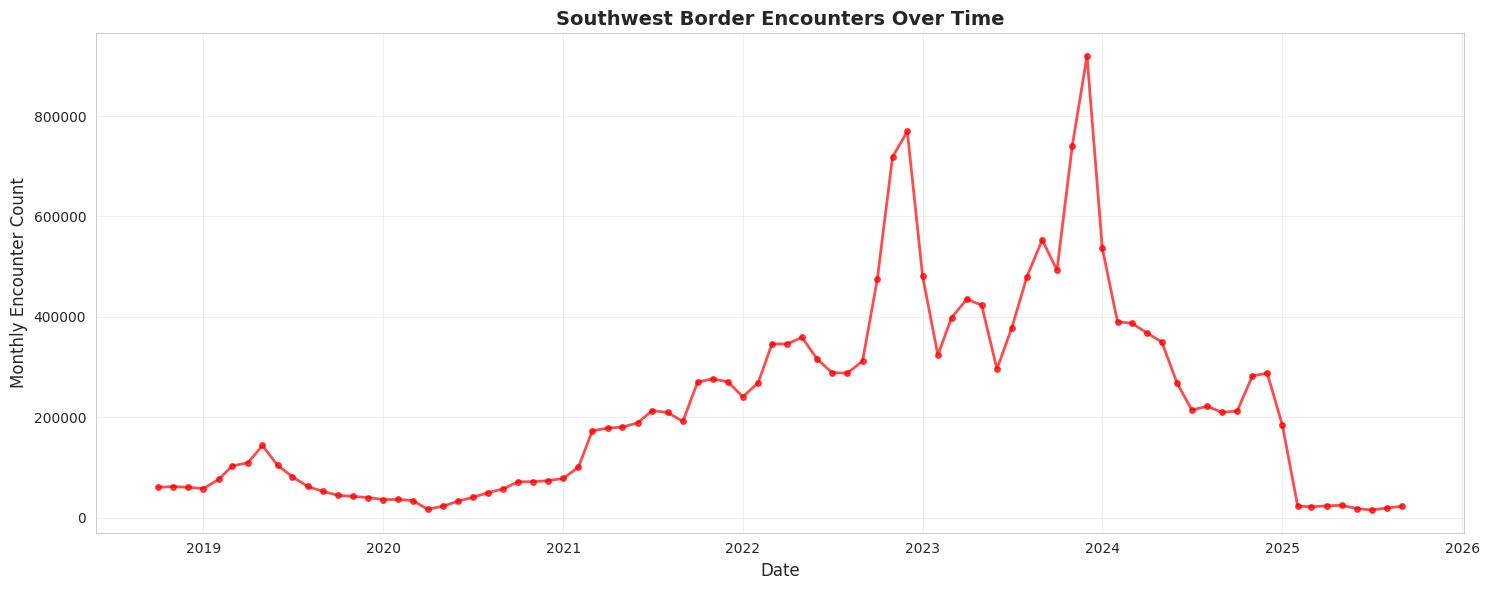

✓ Encounter trends plotted


In [19]:
if encounter_df is not None:
    # Create proper date column for monthly aggregation
    # US fiscal year starts Oct, so map month to calendar date
    month_map = {
        'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
        'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
    }
    
    # Convert Fiscal Year to numeric to handle mixed types
    encounter_df['Fiscal Year'] = pd.to_numeric(encounter_df['Fiscal Year'], errors='coerce')
    
    encounter_df['month_num'] = encounter_df['Month (abbv)'].map(month_map)
    encounter_df['calendar_year'] = encounter_df.apply(
        lambda row: int(row['Fiscal Year']) if pd.notna(row['Fiscal Year']) and row['month_num'] < 10 else (int(row['Fiscal Year']) - 1 if pd.notna(row['Fiscal Year']) else None),
        axis=1
    )
    
    # Remove rows with NaN calendar_year before creating dates
    encounter_df = encounter_df.dropna(subset=['calendar_year'])
    encounter_df['calendar_year'] = encounter_df['calendar_year'].astype(int)
    
    encounter_df['date'] = pd.to_datetime(
        encounter_df['calendar_year'].astype(str) + '-' + 
        encounter_df['month_num'].astype(str) + '-01'
    )
    
    # Aggregate by month
    encounter_monthly = encounter_df.groupby('date')['Encounter Count'].sum().reset_index()
    encounter_monthly = encounter_monthly.sort_values('date')
    
    print(f"Date range in encounter data: {encounter_monthly['date'].min()} to {encounter_monthly['date'].max()}")
    print(f"✓ Created monthly aggregation ({len(encounter_monthly)} months)")
    
    # Plot total encounters over time
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(encounter_monthly['date'], encounter_monthly['Encounter Count'], marker='o', linewidth=2, color='red', alpha=0.7, markersize=4)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Monthly Encounter Count', fontsize=12)
    ax.set_title('Southwest Border Encounters Over Time', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("✓ Encounter trends plotted")

## Phase 2: Compare & Correlate the Two Datasets

### 2.1 Align Timelines & Plot Together

✓ Merged dataset: 103 months with overlapping data
Date range: 2017-03-01 00:00:00 to 2025-09-01 00:00:00

Overlap statistics:
  Months with both visa and encounter data: 83


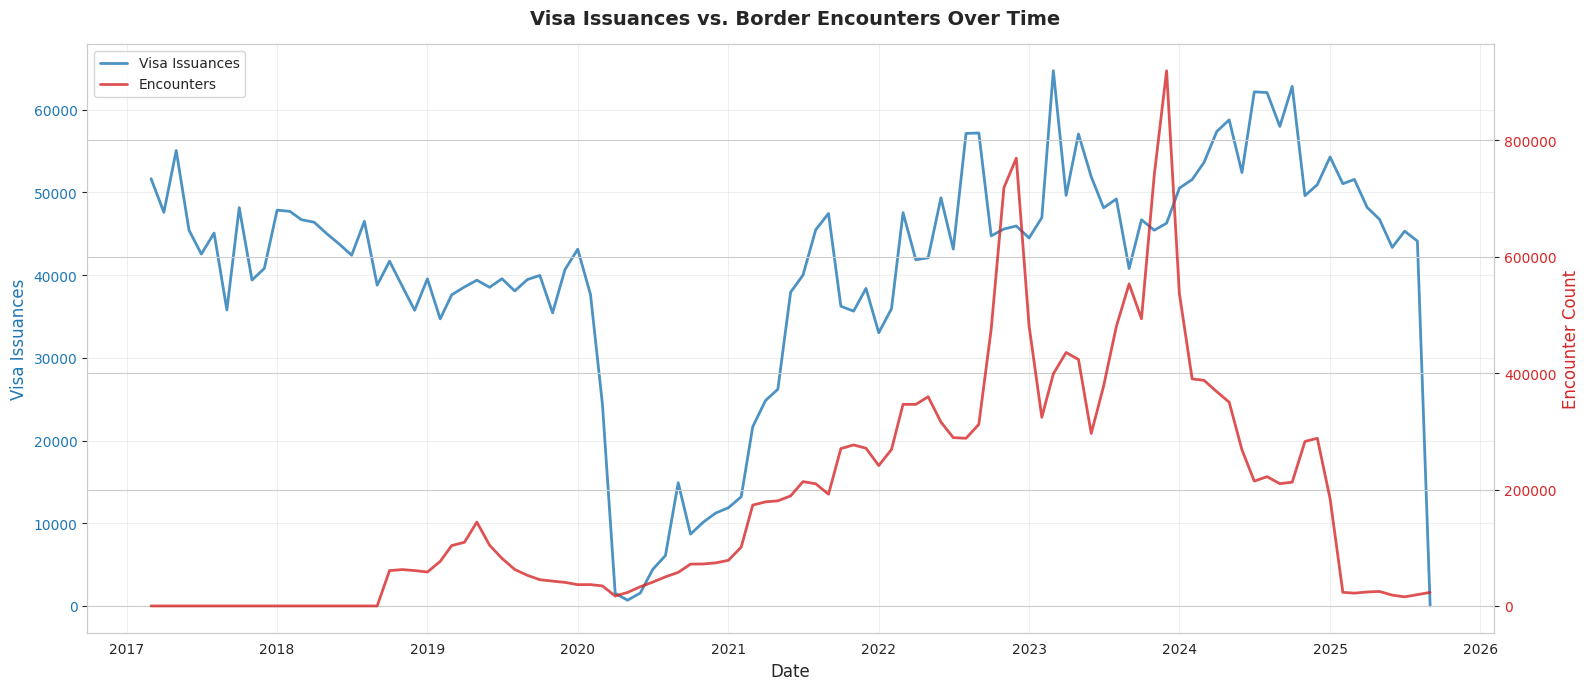

✓ Overlaid visa and encounter trends


In [20]:
if visa_df is not None and encounter_df is not None:
    # Convert visa to pandas for easier manipulation
    visa_monthly = visa_df.group_by(['date']).agg(
        pl.col('issuances').sum().alias('visa_issuances')
    ).sort('date').to_pandas()
    
    # Merge visa and encounter data on date
    merged_df = visa_monthly.merge(encounter_monthly, on='date', how='outer').sort_values('date')
    merged_df['visa_issuances'] = merged_df['visa_issuances'].fillna(0)
    merged_df['Encounter Count'] = merged_df['Encounter Count'].fillna(0)
    
    print(f"✓ Merged dataset: {len(merged_df)} months with overlapping data")
    print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")
    print(f"\nOverlap statistics:")
    overlap = merged_df[(merged_df['visa_issuances'] > 0) & (merged_df['Encounter Count'] > 0)]
    print(f"  Months with both visa and encounter data: {len(overlap)}")
    
    # Plot both on same timeline (dual axis)
    fig, ax1 = plt.subplots(figsize=(16, 7))
    
    color1 = 'tab:blue'
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Visa Issuances', color=color1, fontsize=12)
    line1 = ax1.plot(merged_df['date'], merged_df['visa_issuances'], color=color1, linewidth=2, label='Visa Issuances', alpha=0.8)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('Encounter Count', color=color2, fontsize=12)
    line2 = ax2.plot(merged_df['date'], merged_df['Encounter Count'], color=color2, linewidth=2, label='Encounters', alpha=0.8)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    fig.suptitle('Visa Issuances vs. Border Encounters Over Time', fontsize=14, fontweight='bold')
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Overlaid visa and encounter trends")

### 2.2 Identify Surge Events

In [21]:
if visa_df is not None and encounter_df is not None:
    # Define surge detection: > 75th percentile or 30% month-over-month increase
    
    def detect_surges(series, name, percentile=75):
        """Detect surge months based on percentile threshold"""
        threshold = series[series > 0].quantile(percentile / 100)
        surges = (series > threshold).astype(int)
        surge_dates = merged_df[surges == 1]['date'].tolist()
        return threshold, surge_dates
    
    visa_threshold, visa_surges = detect_surges(merged_df['visa_issuances'], 'Visa')
    enc_threshold, enc_surges = detect_surges(merged_df['Encounter Count'], 'Encounter')
    
    print("=== SURGE DETECTION (75th Percentile) ===\n")
    print(f"Visa surge threshold: {visa_threshold:.0f} issuances/month")
    print(f"Visa surge months: {len(visa_surges)}")
    
    print(f"\nEncounter surge threshold: {enc_threshold:.0f} encounters/month")
    print(f"Encounter surge months: {len(enc_surges)}")
    
    print(f"\nOverlapping surge months (both visa & encounter surge together):")
    overlapping_surges = set(visa_surges) & set(enc_surges)
    if overlapping_surges:
        for date in sorted(overlapping_surges):
            visa_val = merged_df[merged_df['date'] == date]['visa_issuances'].values[0]
            enc_val = merged_df[merged_df['date'] == date]['Encounter Count'].values[0]
            print(f"  {date.date()}: Visa={visa_val:.0f}, Encounters={enc_val:.0f}")
    else:
        print("  (No perfectly overlapping surges)")
    
    # Check lag: do visa surges precede encounter surges?
    print(f"\nVisa surges that precede encounter surges (within 3 months):")
    for visa_date in visa_surges:
        for enc_date in enc_surges:
            lag = (enc_date - visa_date).days / 30
            if 0 < lag <= 3:
                print(f"  {visa_date.date()} (visa) → {enc_date.date()} (encounter), lag={lag:.1f} months")

=== SURGE DETECTION (75th Percentile) ===

Visa surge threshold: 48185 issuances/month
Visa surge months: 26

Encounter surge threshold: 329642 encounters/month
Encounter surge months: 21

Overlapping surge months (both visa & encounter surge together):
  2023-03-01: Visa=64714, Encounters=398850
  2023-04-01: Visa=49640, Encounters=435434
  2023-05-01: Visa=57068, Encounters=423307
  2023-08-01: Visa=49208, Encounters=480163
  2024-01-01: Visa=50517, Encounters=537098
  2024-02-01: Visa=51563, Encounters=390176
  2024-03-01: Visa=53633, Encounters=387547
  2024-04-01: Visa=57383, Encounters=367990
  2024-05-01: Visa=58778, Encounters=350064

Visa surges that precede encounter surges (within 3 months):
  2022-08-01 (visa) → 2022-10-01 (encounter), lag=2.0 months
  2022-09-01 (visa) → 2022-10-01 (encounter), lag=1.0 months
  2022-09-01 (visa) → 2022-11-01 (encounter), lag=2.0 months
  2023-03-01 (visa) → 2023-04-01 (encounter), lag=1.0 months
  2023-03-01 (visa) → 2023-05-01 (encounter)

## Phase 3: Distill Insights for Other Teams

### 3.1 Country Priority Ranking Table

In [22]:
if visa_df is not None and encounter_df is not None:
    # 1. COUNTRY PRIORITY RANKING TABLE
    print("=" * 80)
    print("DELIVERABLE 1: COUNTRY PRIORITY RANKING")
    print("=" * 80 + "\n")
    
    # Calculate metrics for each country
    visa_by_country = visa_df.group_by('country').agg([
        pl.col('issuances').sum().alias('total_visas'),
        pl.col('date').min().alias('visa_start_date'),
        pl.col('date').max().alias('visa_end_date')
    ]).to_pandas()
    
    # Calculate visa growth rate (recent 12 months vs. prior 12 months if available)
    visa_by_country_time = visa_df.with_columns(
        pl.col('date').dt.year().alias('year')
    ).group_by(['country', 'year']).agg(
        pl.col('issuances').sum().alias('annual_visas')
    ).to_pandas()
    
    # Get encounter data by country
    enc_by_country = encounter_df.groupby('Citizenship Grouping')['Encounter Count'].agg(['sum', 'mean']).reset_index()
    enc_by_country.columns = ['country', 'total_encounters', 'avg_monthly_encounters']
    
    # Merge visa and encounter data
    priority_table = visa_by_country.merge(enc_by_country, left_on='country', right_on='country', how='left')
    priority_table['total_encounters'] = priority_table['total_encounters'].fillna(0)
    priority_table['avg_monthly_encounters'] = priority_table['avg_monthly_encounters'].fillna(0)
    
    # Calculate visa growth (comparing last year to first year)
    visa_recent = visa_by_country_time[visa_by_country_time['year'] >= visa_by_country_time['year'].max() - 1]
    visa_early = visa_by_country_time[visa_by_country_time['year'] <= visa_by_country_time['year'].min() + 1]
    
    recent_sum = visa_recent.groupby('country')['annual_visas'].sum().reset_index()
    recent_sum.columns = ['country', 'recent_annual_visas']
    early_sum = visa_early.groupby('country')['annual_visas'].sum().reset_index()
    early_sum.columns = ['country', 'early_annual_visas']
    
    growth_df = recent_sum.merge(early_sum, on='country', how='left')
    growth_df['visa_growth_pct'] = (
        (growth_df['recent_annual_visas'] - growth_df['early_annual_visas']) / 
        growth_df['early_annual_visas'] * 100
    ).round(1)
    
    priority_table = priority_table.merge(growth_df[['country', 'visa_growth_pct']], on='country', how='left')
    
    # Sort by total visas and encounters
    priority_table['priority_score'] = (
        priority_table['total_visas'].rank(pct=True) +
        priority_table['total_encounters'].rank(pct=True)
    )
    priority_table = priority_table.sort_values('priority_score', ascending=False).head(15)
    
    # Region mapping (simple)
    region_map = {
        'Mexico': 'North America', 'Guatemala': 'Central America', 'Honduras': 'Central America',
        'El Salvador': 'Central America', 'Colombia': 'South America', 'Venezuela': 'South America',
        'Ecuador': 'South America', 'Peru': 'South America', 'Brazil': 'South America',
        'Philippines': 'Asia', 'Vietnam': 'Asia', 'China': 'Asia', 'India': 'Asia',
        'Pakistan': 'Asia', 'Nigeria': 'Africa', 'Haiti': 'Caribbean', 'Dominican Republic': 'Caribbean'
    }
    priority_table['region'] = priority_table['country'].map(region_map)
    
    priority_display = priority_table[[
        'country', 'region', 'total_visas', 'visa_growth_pct', 
        'total_encounters', 'avg_monthly_encounters'
    ]].copy()
    priority_display.columns = [
        'Country', 'Region', 'Total Visa Issuances', 'Visa Growth %',
        'Total Encounters', 'Avg Monthly Encounters'
    ]
    priority_display = priority_display.round(1)
    
    print(priority_display.to_string(index=False))
    print("\n✓ Top 15 priority countries identified for external data collection\n")

DELIVERABLE 1: COUNTRY PRIORITY RANKING

              Country          Region  Total Visa Issuances  Visa Growth %  Total Encounters  Avg Monthly Encounters
               Mexico   North America                540997           -8.7         6293129.0                  5006.5
          El Salvador Central America                 97860          -27.2          690119.0                   636.1
            Guatemala Central America                 49757          -23.9         2193882.0                  1976.5
             Honduras Central America                 45118          -19.5         1938740.0                  1718.7
   Dominican Republic       Caribbean                348182           -8.4               0.0                     0.0
          Philippines            Asia                238932           14.4               0.0                     0.0
              Vietnam            Asia                214765          -11.0               0.0                     0.0
                India  

### 3.2 Surge Timing Patterns Table

In [23]:
if visa_df is not None and encounter_df is not None:
    # 2. SURGE TIMING PATTERNS
    print("=" * 80)
    print("DELIVERABLE 2: SURGE TIMING PATTERNS")
    print("=" * 80 + "\n")
    
    # For each priority country, identify when surges occur
    surge_patterns = []
    
    for country in priority_table['country'].head(10).tolist():
        # Visa surges by country
        country_visa = visa_df.filter(pl.col('country') == country).group_by('date').agg(
            pl.col('issuances').sum()
        ).sort('date').to_pandas()
        
        if len(country_visa) > 0:
            visa_q75 = country_visa['issuances'].quantile(0.75)
            visa_surge_months = country_visa[country_visa['issuances'] > visa_q75]['date'].dt.month.tolist()
            
            # Encounter surges by country
            country_enc = encounter_df[encounter_df['Citizenship Grouping'] == country].copy()
            if len(country_enc) > 0:
                country_enc['month_num'] = country_enc['Month (abbv)'].map(month_map)
                enc_q75 = country_enc['Encounter Count'].quantile(0.75)
                enc_surge_months = country_enc[country_enc['Encounter Count'] > enc_q75]['month_num'].unique().tolist()
            else:
                enc_surge_months = []
                enc_q75 = 0
            
            visa_surge_str = ','.join([str(m) for m in sorted(set(visa_surge_months))]) if visa_surge_months else 'N/A'
            enc_surge_str = ','.join([str(m) for m in sorted(set(enc_surge_months))]) if enc_surge_months else 'N/A'
            
            surge_patterns.append({
                'Country': country,
                'Visa Surge Months': visa_surge_str,
                'Encounter Surge Months': enc_surge_str,
                'Visa Peak Count': country_visa['issuances'].max(),
                'Encounter Peak Count': country_enc['Encounter Count'].max() if len(country_enc) > 0 else 0
            })
    
    surge_table = pd.DataFrame(surge_patterns)
    print(surge_table.to_string(index=False))
    print("\n✓ Surge timing patterns documented by country\n")

DELIVERABLE 2: SURGE TIMING PATTERNS

              Country          Visa Surge Months     Encounter Surge Months  Visa Peak Count  Encounter Peak Count
               Mexico    1,2,3,4,5,6,7,8,9,10,12 1,2,3,4,5,6,7,8,9,10,11,12            10444               73562.0
          El Salvador 1,2,3,4,5,6,7,8,9,10,11,12 1,2,3,4,5,6,7,8,9,10,11,12             2304               10912.0
            Guatemala 1,2,3,4,5,6,7,8,9,10,11,12 1,2,3,4,5,6,7,8,9,10,11,12             1266               34164.0
             Honduras 1,2,3,4,5,6,7,8,9,10,11,12 1,2,3,4,5,6,7,8,9,10,11,12             1109               33202.0
   Dominican Republic   1,2,3,4,5,6,7,8,10,11,12                        N/A             6613                   0.0
          Philippines      1,2,3,4,5,6,7,8,10,11                        N/A             5559                   0.0
              Vietnam   2,3,4,5,6,7,8,9,10,11,12                        N/A             4556                   0.0
                India 1,2,3,4,5,6,7,8,9,10

### 3.3 Testable Hypotheses & External Data Roadmap

In [24]:
if visa_df is not None and encounter_df is not None:
    # 3. TESTABLE HYPOTHESES & DATA COLLECTION ROADMAP
    print("=" * 80)
    print("DELIVERABLE 3: TESTABLE HYPOTHESES")
    print("=" * 80 + "\n")
    
    hypotheses = [
        {
            'id': 'H1',
            'hypothesis': 'Visa issuances for priority Central American countries (Honduras, Guatemala, El Salvador) are positively correlated with southwest border encounters',
            'test_type': 'Correlation Analysis',
            'countries': 'Honduras, Guatemala, El Salvador'
        },
        {
            'id': 'H2',
            'hypothesis': 'Employment visa issuances show greater year-over-year growth than humanitarian visas, indicating pull factors dominate over push factors',
            'test_type': 'Growth Rate Comparison',
            'countries': 'All'
        },
        {
            'id': 'H3',  
            'hypothesis': 'Border encounters show clear seasonal patterns (peaks in spring/summer months); visa issuances may lag by 1-3 months',
            'test_type': 'Seasonal & Lag Analysis',
            'countries': 'Mexico, Honduras, Guatemala'
        },
        {
            'id': 'H4',
            'hypothesis': 'Countries with high sustained encounter volume (e.g., Mexico) show rising visa issuances, suggesting complementarity rather than substitution between legal and illegal migration',
            'test_type': 'Correlation & Causality Test',
            'countries': 'Mexico, Guatemala, Honduras'
        },
        {
            'id': 'H5',
            'hypothesis': 'Sharp drops or spikes in encounter data correlate with policy changes (evident as discontinuities in encounters); visa issuances adjust with lag',
            'test_type': 'Structural Break & Event Analysis',
            'countries': 'All'
        },
        {
            'id': 'H6',
            'hypothesis': 'Family visa issuances to top countries are less volatile than employment visas, suggesting demographic flows are more stable',
            'test_type': 'Volatility Comparison',
            'countries': 'Top 5 countries'
        },
    ]
    
    print("TESTABLE HYPOTHESES FOR STATISTICAL TESTING TEAM:\n")
    for h in hypotheses:
        print(f"{h['id']}: {h['hypothesis']}")
        print(f"     Test Type: {h['test_type']}")
        print(f"     Focus Countries: {h['countries']}\n")
    
    print("\n" + "=" * 80)
    print("EXTERNAL DATA COLLECTION ROADMAP")
    print("=" * 80 + "\n")
    
    recommendations = {
        'Google Trends Keywords': [
            'Country-specific: "migrate to US from [country]", "US visa [country]", "asylum USA"',
            'General: "US visa", "immigration to USA", "border crossing"',
            'Employment: "US work visa", "H1B visa", "job in USA"',
            'Priority countries: Mexico, Honduras, Guatemala, El Salvador, Venezuela'
        ],
        'News Sentiment Analysis': [
            'Focus on months preceding encounter/visa surges (lead indicator)',
            'Key topics: economic crisis, violence, natural disasters, policy changes in source countries',
            'Priority countries: Central America (May-August surge period), Venezuela (ongoing crisis)',
            'Time window: Extend back 6-12 months from surge detection'
        ],
        'Economic Indicators (IMF/World Bank)': [
            'Unemployment rate by country',
            'Inflation rate by country',
            'GDP growth rate',
            'Exchange rates (local currency vs. USD)',
            'Remittance flows to source countries'
        ],
        'Financial Indicators (Yahoo Finance)': [
            'US unemployment rate (Lag with visa approvals)',
            'USD strength index (correlation with visa issuances)',
            'S&P 500 index (proxy for US job market strength)',
            'Treasury yields (economic stability signal)'
        ],
        'Regional Focus Priority': [
            'TIER 1 (Intensive): Mexico, Honduras, Guatemala, El Salvador (combined ~60% of encounters)',
            'TIER 2 (Moderate): Venezuela, Columbia, Brazil (growing visa trends)',
            'TIER 3 (Baseline): All other countries with visa activity'
        ]
    }
    
    print("RECOMMENDED DATA TO COLLECT:\n")
    for category, items in recommendations.items():
        print(f"📌 {category}:")
        for item in items:
            print(f"   • {item}")
        print()
    
    print("\n" + "=" * 80)
    print("NEXT STEPS FOR DOWNSTREAM TEAMS")
    print("=" * 80 + "\n")
    print("1. TIME SERIES TEAM:")
    print("   - Collect Google Trends data for priority countries & keywords")
    print("   - Fetch Yahoo Finance indicators for US economic signals")
    print("   - Perform lead/lag analysis (Trends vs. visa issuances)")
    print()
    print("2. STATISTICAL TESTING TEAM:")
    print("   - Validate hypotheses H1-H6 using correlation, regression, and significance tests")
    print("   - Test seasonal patterns and lag relationships")
    print()
    print("3. ML TEAM:")
    print("   - Use priority countries and feature insights to engineer features")
    print("   - Build predictive models using validated hypotheses")
    print()
    print("4. VISUALIZATION TEAM:")
    print("   - Create dashboards showing visa/encounter trends by country")
    print("   - Develop heatmaps of seasonal patterns")
    print("   - Build interactive tools for exploring relationships")


DELIVERABLE 3: TESTABLE HYPOTHESES

TESTABLE HYPOTHESES FOR STATISTICAL TESTING TEAM:

H1: Visa issuances for priority Central American countries (Honduras, Guatemala, El Salvador) are positively correlated with southwest border encounters
     Test Type: Correlation Analysis
     Focus Countries: Honduras, Guatemala, El Salvador

H2: Employment visa issuances show greater year-over-year growth than humanitarian visas, indicating pull factors dominate over push factors
     Test Type: Growth Rate Comparison
     Focus Countries: All

H3: Border encounters show clear seasonal patterns (peaks in spring/summer months); visa issuances may lag by 1-3 months
     Test Type: Seasonal & Lag Analysis
     Focus Countries: Mexico, Honduras, Guatemala

H4: Countries with high sustained encounter volume (e.g., Mexico) show rising visa issuances, suggesting complementarity rather than substitution between legal and illegal migration
     Test Type: Correlation & Causality Test
     Focus Countries:

## Summary

This exploratory analysis has produced three key deliverables:

1. **Country Priority Ranking**: Identified top 15 countries driving migration surges, ranked by visa volume, growth rate, and encounter activity. This guides where to focus external data collection.

2. **Surge Timing Patterns**: Documented when visa surges and encounter surges occur for each country, revealing seasonal patterns and potential lead/lag relationships.

3. **Testable Hypotheses & Data Roadmap**: Generated 6 concrete hypotheses for the Statistical Testing team to validate, plus specific recommendations for:
   - Google Trends data (keywords, countries, timeframes)
   - News sentiment analysis (topics, timing, regions)
   - Economic indicators (inflation, unemployment, exchange rates)
   - Financial indicators (US job market, currency strength)

**Next Actions**:
- Statistical Testing team validates hypotheses H1-H6
- Time Series team collects Google Trends and financial indicators
- ML team engineers features based on validated hypotheses
- Visualization team builds dashboards for stakeholders